# DAY 5 PRACTICE TASK

### Use the Titanic dataset.

## Task 1 — Load

In [ ]:
import pandas as pd

df = pd.read_csv("../../dataset/titanic/train.csv")

## Task 2 — Separate target

In [10]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

## Task 3 — Select numerical features

In [11]:
X_numeric = X.select_dtypes(include="number")

## Task 4 — Correlation

### Find the correlation of numerical features with:

Survived

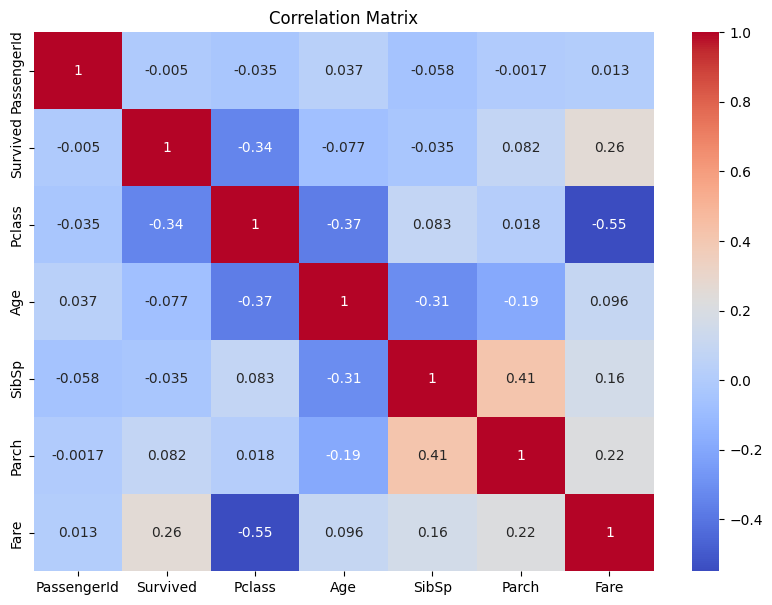

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../../dataset/titanic/train.csv")

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Task 5 — Variance

Use:

VarianceThreshold

In [13]:
from sklearn.feature_selection import VarianceThreshold

X = df.select_dtypes(include="number").drop(columns=["Survived"])

selector = VarianceThreshold(threshold=0.0)
X_selected = selector.fit_transform(X)

print("X shape:", X.shape)
print("Selected shape", X_selected.shape)

X shape: (891, 6)
Selected shape (891, 6)


## Task 6 — SelectKBest

Select:

Top 5 features

using:

f_classif

In [14]:
from sklearn.feature_selection import SelectKBest, f_classif

# 1. Separate features and target
X = df.drop("Survived", axis=1)
y = df["Survived"]

# 2. Keep only numeric features
X = X.select_dtypes(include="number")

# 3. Fill missing values
X = X.fillna(X.median())

# 4. Create SelectKBest
selector = SelectKBest(score_func=f_classif, k=5)

# 5. Fit and transform
X_new = selector.fit_transform(X, y)

# 6. Get selected feature names
selected_features = X.columns[selector.get_support()]

# 7. Display results
print("Selected Features:")
print(selected_features)

print("\nNew Shape:")
print(X_new.shape)

Selected Features:
Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

New Shape:
(891, 5)


## Task 7 — Feature Importance

Train:

RandomForestClassifier

In [15]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42
)

model.fit(X, y)


importance = model.feature_importances_



feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by = "Importance",
    ascending = False
)

print(feature_importance)

       Feature  Importance
0  PassengerId    0.303801
5         Fare    0.293749
2          Age    0.234644
1       Pclass    0.079918
3        SibSp    0.048893
4        Parch    0.038994
